         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0788 - val_loss: 0.0142
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0138 - val_loss: 0.0124
Epoch 3/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0128 - val_loss: 0.0111
Epoch 4/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0118 - val_loss: 0.0101
Epoch 5/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0110 - val_loss: 0.0093
Epoch 6/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0105 - val_loss: 0.0088
Epoch 7/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0103 - val_loss: 0.0087
Epoch 8/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0102 - val_loss: 0.0083
Epoch 9/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0101 - val_loss: 0.0083
Epoch 10/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0101 - val_loss: 0.0082
Epoch 11/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0101 - val_loss: 0.0082
Epoch 12/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

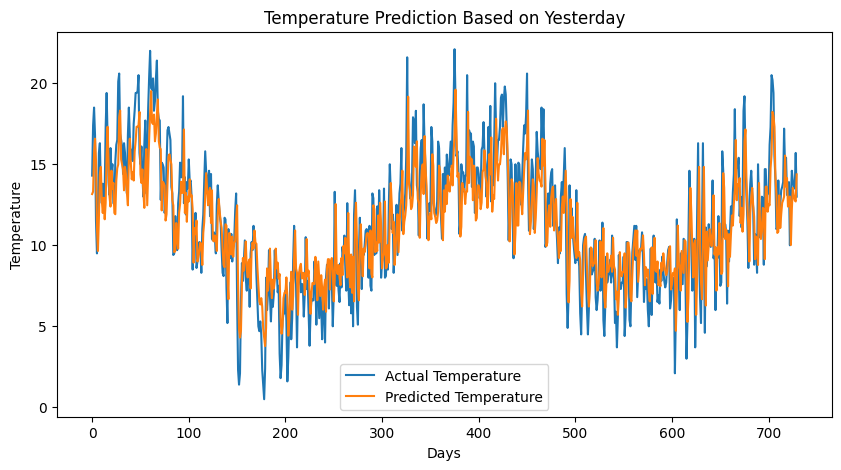

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Today's Temperature: 12.30936


In [1]:
# Install libraries (if needed)
!pip -q install tensorflow

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset automatically
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

print(df.head())

# Select temperature column
data = df[['Temp']]

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Create Yesterday -> Today dataset
X = []
y = []

for i in range(1, len(scaled_data)):
    X.append(scaled_data[i-1])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = X.reshape((X.shape[0],1,1))

# Train-Test Split
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

# Build LSTM Model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(1,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train Model
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test,y_test),
    verbose=1
)

# Prediction
predictions = model.predict(X_test)

# Convert back to original values
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test)

# Plot Graph
plt.figure(figsize=(10,5))
plt.plot(actual, label="Actual Temperature")
plt.plot(predictions, label="Predicted Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.title("Temperature Prediction Based on Yesterday")
plt.legend()
plt.show()

# Predict Today's Temperature
last_day = scaled_data[-1]
last_day = last_day.reshape((1,1,1))

today_prediction = model.predict(last_day)
today_prediction = scaler.inverse_transform(today_prediction)

print("Predicted Today's Temperature:", today_prediction[0][0])